# Analysis of Trained Models

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# System imports
from pathlib import Path
import sys
from datetime import date
from collections import defaultdict
import json

# Plotting imports
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

# Scientific imports
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from scipy.stats import zscore, spearmanr
from scipy.cluster import hierarchy
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram

# NN imports
import torch
import neurogym as ngym

# For import from src folder in linux
ROOT = Path().cwd().parent
SRC_PATH = ROOT / 'src'
sys.path.append(str(ROOT))
sys.path.append(str(SRC_PATH))

# Custom imports
from src.environments import TAMTask, MotionTask, load_motion_from_image, load_tam_from_image
from src.train_test_utils import plot_dataset, plot_training_curves
from src.networks import TAMNet
from src.utils import load_params

In [84]:
# Plotting settings
custom_palette = sns.color_palette(["#E74C3C", "#2ECC71"]) # a custom palette with red and green
custom_params = {
    "axes.spines.right": False,
    "axes.spines.top": False
}
sns.set_theme(
    font_scale=1,
    style='white',
    context='poster',
    font='Arial',
    rc=custom_params
)

In [4]:
# Set directories
# Figures
today = date.today().strftime('%m-%d-%Y')
FIG_DIR = ROOT / 'figures' / today
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Network
MODEL_DIR = ROOT / 'data' / 'models'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Stimuli
STIM_DIR = ROOT / 'data' / 'stimuli' / "TAM_basic"

In [5]:
# Load parameters
params = load_params(str(ROOT / 'parameters.json'))
exp_params = params["EXPERIMENT"]
env_params = params['TASK']
net_params = params['NETWORK']

In [12]:
motion_dirs = ["horizontal"]
box_shapes = ["square", "circle", "triangle"]
img_size = 32
batch_size = 128
seq_len = 100

# Create environments and datasets
tam_test_datasets = defaultdict()
motion_test_datasets = defaultdict()
tam_types = ["tam", "outline"]
# motion_types = ["cnt", "track"]
motion_types = ["cnt"]

for bs in box_shapes:
    for tt in tam_types:
        for md in motion_dirs:
            print(bs, tt, md)
            if tt == "tam":
                _path = STIM_DIR
            else:
                _path = STIM_DIR.parent / "TAM_outline"

            stimuli = load_tam_from_image(img_size, stim_type=tt, stim_path=_path)
            env = TAMTask(
                box_shape=bs,
                stimuli=stimuli,
                stim_type=tt,
                stim_ori=md,
                dt=env_params["dt"],
                sigma=0.01,
                img_size=img_size
            )
            env.reset(no_step=True)

            # Generate dataset object
            dataset = ngym.Dataset(
                env,
                batch_size=batch_size,
                seq_len=seq_len
            )

            # Add dataset to dictionary
            tam_test_datasets[f'{bs}-{tt}-{md}'] = env
            tam_test_datasets[f'{bs}-{tt}-{md}'] = dataset

for bs in box_shapes:
    for mt in motion_types:
        for md in motion_dirs:

            print(bs, mt, md)

            stimuli = load_motion_from_image(img_size, stim_path=STIM_DIR.parent / "motion_task")
            env = MotionTask(
                dt=env_params["dt"],
                box_shape=bs,
                motion_type=mt,
                stim_ori=md,
                stimuli=stimuli,
                sigma=0,
                img_size=img_size
            )
            env.reset(no_step=True)

            # Generate dataset object
            dataset = ngym.Dataset(
                env,
                batch_size=batch_size,
                seq_len=seq_len
            )

            # Add dataset to dictionary
            motion_test_datasets[f'{bs}-{mt}-{md}'] = env
            motion_test_datasets[f'{bs}-{mt}-{md}'] = dataset

square tam horizontal
square outline horizontal
circle tam horizontal
circle outline horizontal
triangle tam horizontal
triangle outline horizontal
square cnt horizontal
circle cnt horizontal
triangle cnt horizontal


In [142]:
device = torch.device(net_params["device"])

net = TAMNet(
    dataset=tam_test_datasets["square-tam-horizontal"],
    hidden_size=256,
    output_size=4,
    learning_rate=0.01,
    device=device
)

# Load the trained weights
net.RNN.load_state_dict(torch.load(MODEL_DIR / 'learned_horiz_both.pt'))
net.RNN.eval()
net.RNN.rnn.eval()

CTRNN(
  (input2h): Linear(in_features=1024, out_features=256, bias=True)
  (h2h): Linear(in_features=256, out_features=256, bias=True)
)

In [143]:
# Test on other environments
tam_test_accuracies = defaultdict()
tam_test_activities = defaultdict()
tam_infos = defaultdict()
for et, dataset in tam_test_datasets.items():
    info, activity, test_acc = net.test_rnn(500, dataset)
    tam_infos[et] = info
    tam_test_accuracies[et] = test_acc
    tam_test_activities[et] = activity
    print(f'Accuracy on {et} = {test_acc}')

Accuracy on square-tam-horizontal = 1.0
Accuracy on square-outline-horizontal = 0.668
Accuracy on circle-tam-horizontal = 0.768
Accuracy on circle-outline-horizontal = 0.278
Accuracy on triangle-tam-horizontal = 0.794
Accuracy on triangle-outline-horizontal = 0.328


In [144]:
# Test on other environments
motion_test_accuracies = defaultdict()
motion_test_activities = defaultdict()
motion_infos = defaultdict()
for et, dataset in motion_test_datasets.items():
    info, activity, test_acc = net.test_rnn(500, dataset)
    motion_infos[et] = info
    motion_test_accuracies[et] = test_acc
    motion_test_activities[et] = activity
    print(f'Accuracy on {et} = {test_acc}')

Accuracy on square-cnt-horizontal = 1.0
Accuracy on circle-cnt-horizontal = 0.944
Accuracy on triangle-cnt-horizontal = 0.608


# Plot accuracies

In [20]:
tam_accuracy_labels = {
    "Square": tam_test_accuracies["square-tam-horizontal"],
    "Square Outline": tam_test_accuracies["square-outline-horizontal"],
    "Circle": tam_test_accuracies["circle-tam-horizontal"],
    "Circle Outline": tam_test_accuracies["circle-outline-horizontal"],
    "Triangle": tam_test_accuracies["triangle-tam-horizontal"],
    "Triangle Outline": tam_test_accuracies["triangle-outline-horizontal"],
}

motion_test_accuracies = {
    "Square": motion_test_accuracies["square-cnt-horizontal"],
    "Circle": motion_test_accuracies["circle-cnt-horizontal"],
    "Triangle": motion_test_accuracies["triangle-cnt-horizontal"],
}

In [21]:
# Test on other environments
n_runs = 50
orig_tam_acc = np.zeros((len(tam_test_datasets), n_runs))

for r in range(n_runs):
    for i, (et, dataset) in enumerate(tam_test_datasets.items()):
        _, _, test_acc = net.test_rnn(100, dataset)
        orig_tam_acc[i, r] = test_acc

# Test on other environments
n_runs = 50
orig_motion_acc = np.zeros((len(motion_test_datasets), n_runs))

for r in range(n_runs):
    for i, (et, dataset) in enumerate(motion_test_datasets.items()):
        _, _, test_acc = net.test_rnn(100, dataset)
        orig_motion_acc[i, r] = test_acc

In [76]:
tam_test_datasets

defaultdict(None,
            {'square-tam-horizontal': <neurogym.utils.data.Dataset at 0x16efe06a090>,
             'square-outline-horizontal': <neurogym.utils.data.Dataset at 0x16f3c084410>,
             'circle-tam-horizontal': <neurogym.utils.data.Dataset at 0x16e0f8fc410>,
             'circle-outline-horizontal': <neurogym.utils.data.Dataset at 0x16f3c07dd50>,
             'triangle-tam-horizontal': <neurogym.utils.data.Dataset at 0x16f09169450>,
             'triangle-outline-horizontal': <neurogym.utils.data.Dataset at 0x16f0606d7d0>})

In [110]:
orig_tam_acc.mean(axis=1)

array([1.    , 0.6714, 0.8172, 0.3276, 0.772 , 0.3346])

In [111]:
orig_motion_acc.mean(axis=1)

array([1.    , 0.9428, 0.613 ])

In [80]:
np.concatenate((orig_tam_acc, orig_motion_acc), axis=0).shape

(9, 50)

In [109]:
acccc.mean(axis=1)

array([1.    , 0.6714, 0.8172, 0.3276, 0.772 , 0.3346, 1.    , 0.9428,
       0.613 ])

In [115]:
acccc.std(axis=1)

array([0.        , 0.04005047, 0.03741871, 0.04962096, 0.03611094,
       0.05235303, 0.        , 0.02425201, 0.04631414])

In [112]:
list(tam_test_datasets.keys())

['square-tam-horizontal',
 'square-outline-horizontal',
 'circle-tam-horizontal',
 'circle-outline-horizontal',
 'triangle-tam-horizontal',
 'triangle-outline-horizontal']

In [114]:
list(motion_test_datasets.keys())

['square-cnt-horizontal', 'circle-cnt-horizontal', 'triangle-cnt-horizontal']

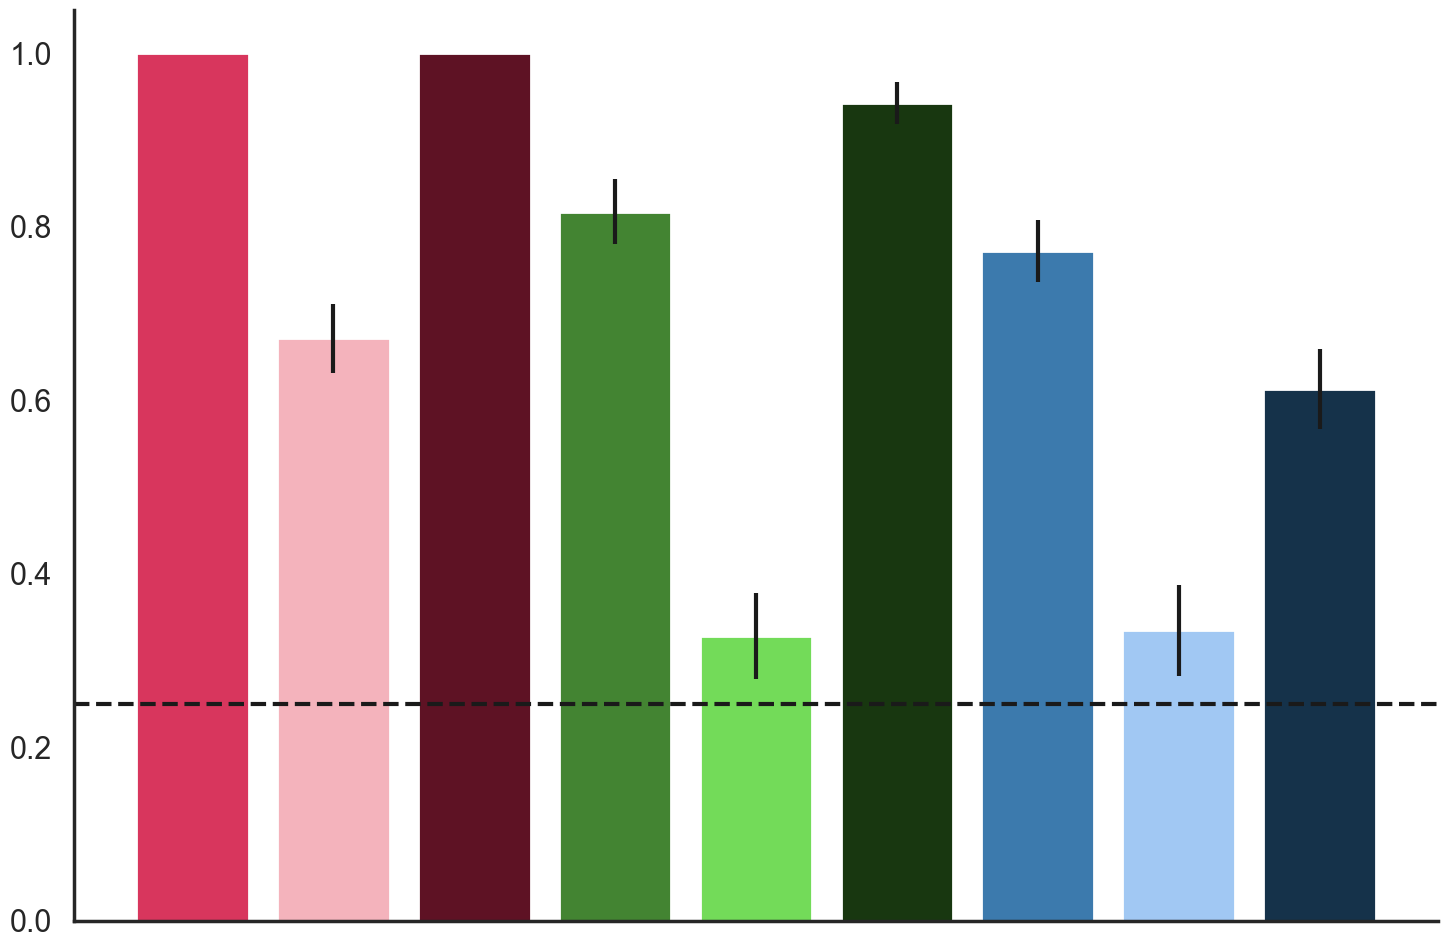

In [116]:
# Plot test accuracy
fig, ax = plt.subplots(1, 1, figsize=(15, 10))
# fig.suptitle("Test accuracy")
acccc = np.concatenate((orig_tam_acc, orig_motion_acc), axis=0)
means_ = acccc.mean(axis=1)
stds_ = acccc.std(axis=1)
# Define colors
colors_high_sat = sns.husl_palette(3, s=0.8, l=0.5)  # 3 colors with high saturation
colors_low_sat = sns.husl_palette(3, s=0.8, l=0.8)  # 3 colors with low saturation
colors_super_sat = sns.husl_palette(3, s=0.8, l=0.2)

means = [means_[0], means_[1], means_[6], means_[2], means_[3], means_[7], means_[4], means_[5], means_[8]]
stds = [stds_[0], stds_[1], stds_[6], stds_[2], stds_[3], stds_[7], stds_[4], stds_[5], stds_[8]]
# Create a new list by interweaving the two color lists
colormap = [val for pair in zip(colors_high_sat, colors_low_sat, colors_super_sat) for val in pair]

ax.bar(np.arange(9), means, yerr=stds, color=colormap)
plt.setp(ax.get_xticklabels(), rotation=45, horizontalalignment='right')
ax.set_xlabel('')
ax.set_xticklabels([])
ax.set_ylabel('')
ax.axhline(y=0.25, color='k', linestyle='--')
# ax.axvline(x=0.5, color='k', linestyle='-')
plt.tight_layout()
plt.savefig(FIG_DIR / 'both_accuracy_TAM.png')

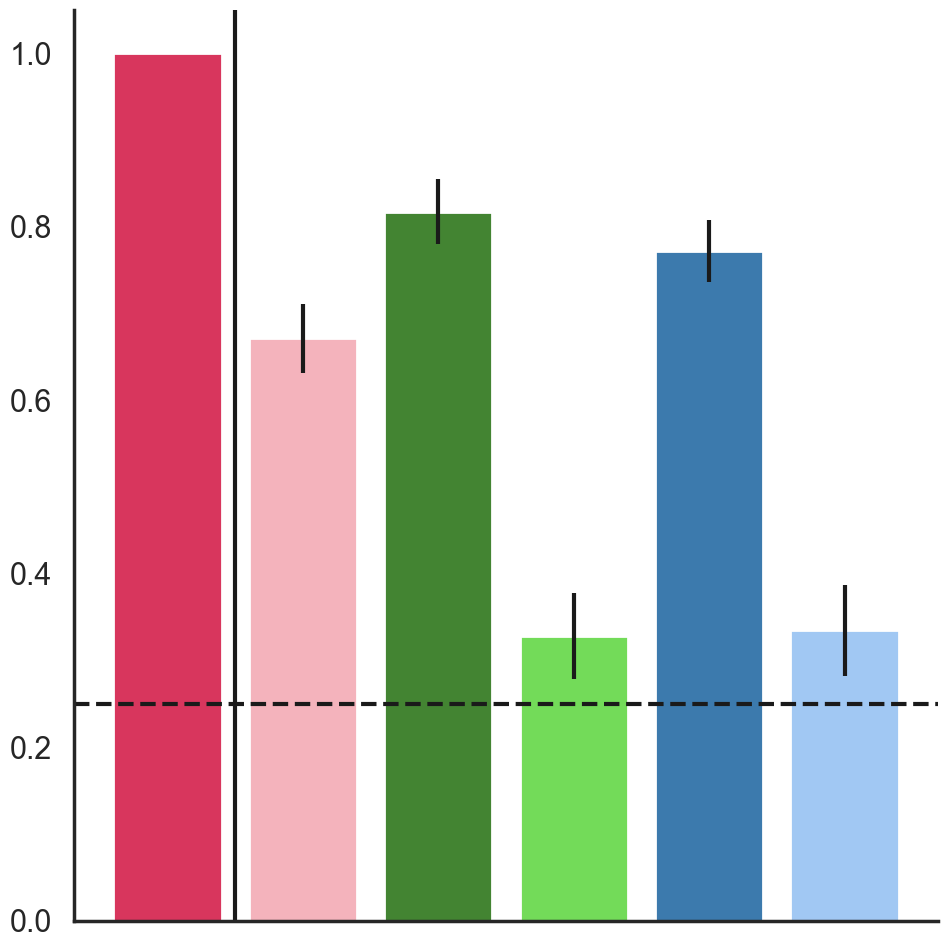

In [22]:
# Plot test accuracy
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
# fig.suptitle("Test accuracy")

# Define colors
colors_high_sat = sns.husl_palette(3, s=0.8, l=0.5)  # 3 colors with high saturation
colors_low_sat = sns.husl_palette(3, s=0.8, l=0.8)  # 3 colors with low saturation

# Create a new list by interweaving the two color lists
colormap = [val for pair in zip(colors_high_sat, colors_low_sat) for val in pair]

ax.bar(np.arange(6), orig_tam_acc.mean(axis=1), yerr=orig_tam_acc.std(axis=1), color=colormap)
plt.setp(ax.get_xticklabels(), rotation=45, horizontalalignment='right')
ax.set_xlabel('')
ax.set_xticklabels([])
ax.set_ylabel('')
ax.axhline(y=0.25, color='k', linestyle='--')
ax.axvline(x=0.5, color='k', linestyle='-')
plt.tight_layout()
plt.savefig(FIG_DIR / 'both_accuracy_TAM.png')

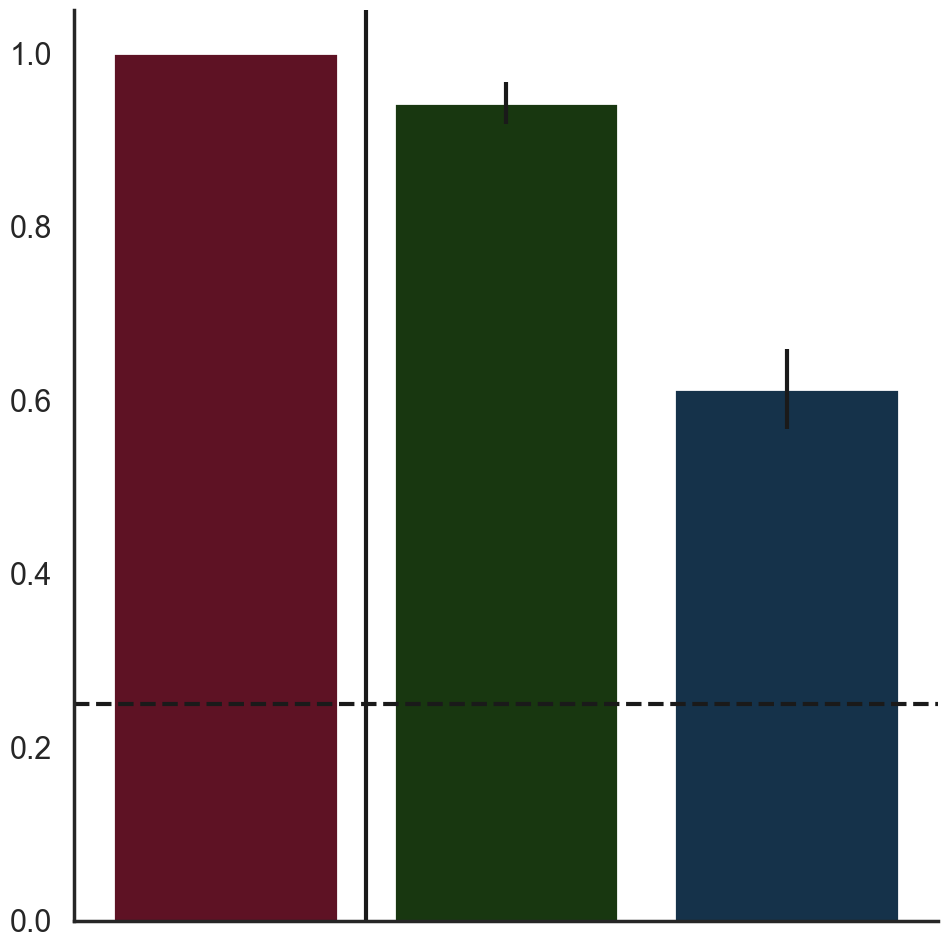

In [26]:
# Plot test accuracy
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
# fig.suptitle("Test accuracy")

# Define colors
colors_super_sat = sns.husl_palette(3, s=0.8, l=0.2)
colors_high_sat = sns.husl_palette(3, s=0.8, l=0.5)  # 3 colors with high saturation
colors_low_sat = sns.husl_palette(3, s=0.8, l=0.8)  # 3 colors with low saturation

# Create a new list by interweaving the two color lists
colormap = [val for pair in zip(colors_high_sat, colors_low_sat) for val in pair]

ax.bar(np.arange(3), orig_motion_acc.mean(axis=1), yerr=orig_motion_acc.std(axis=1), color=colors_super_sat)
# plt.setp(ax.get_xticklabels(), rotation=45, horizontalalignment='right')
ax.set_xlabel('')
ax.set_xticklabels([])
ax.set_ylabel('')
ax.axhline(y=0.25, color='k', linestyle='--')
ax.axvline(x=0.5, color='k', linestyle='-')
plt.tight_layout()
plt.savefig(FIG_DIR / 'both_accuracy_motion.png')

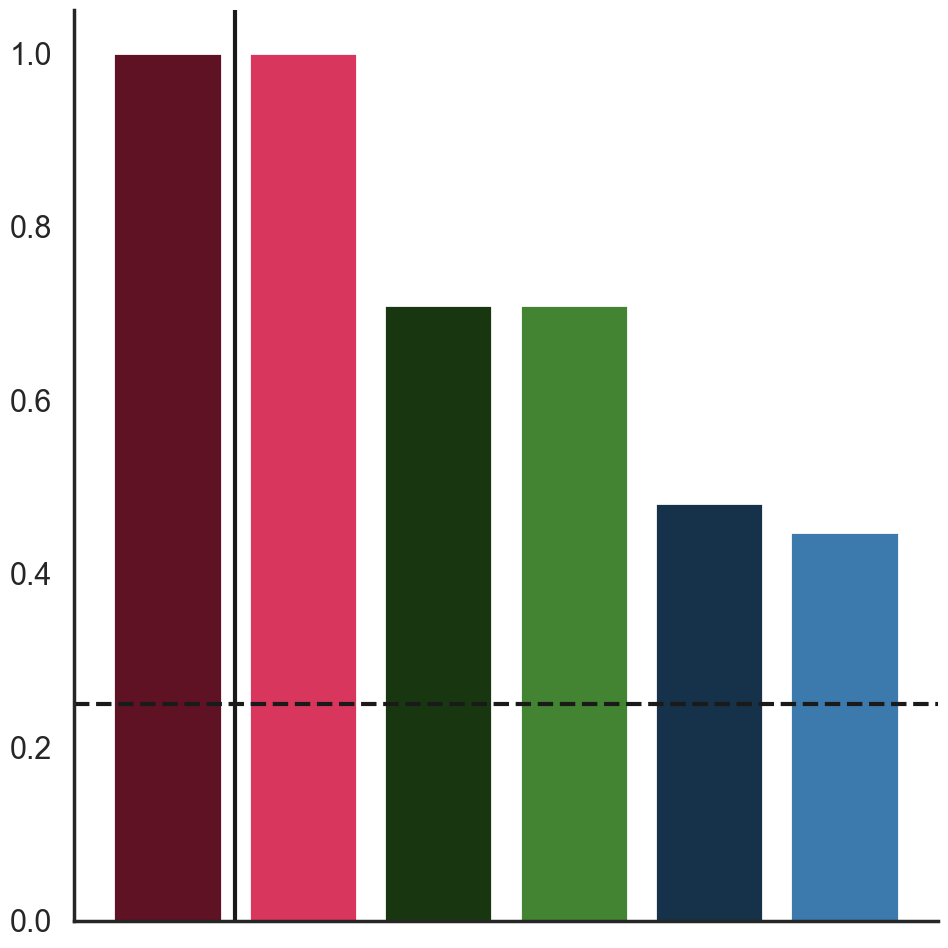

In [14]:
# Plot test accuracy
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
# fig.suptitle("Test accuracy")

# Define colors
colors_high_sat = sns.husl_palette(3, s=0.8, l=0.2)  # 3 colors with high saturation
colors_low_sat = sns.husl_palette(3, s=0.8, l=0.5)  # 3 colors with low saturation

# Create a new list by interweaving the two color lists
colormap = [val for pair in zip(colors_high_sat, colors_low_sat) for val in pair]


ax.bar(accuracy_labels.keys(), accuracy_labels.values(), color=colormap)
plt.setp(ax.get_xticklabels(), rotation=45, horizontalalignment='right')
ax.set_xlabel('')
ax.set_xticklabels([])
ax.set_ylabel('')
ax.axhline(y=0.25, color='k', linestyle='--')
ax.axvline(x=0.5, color='k', linestyle='-')
plt.tight_layout()
plt.savefig(FIG_DIR / 'TAM-basic_TAM-all_test_accuracy_256.png')

In [145]:
# Define PCA to extract 2 components
pca = PCA(n_components=2)
activity = tam_test_activities["square-tam-horizontal"]

# Concatenate activity for PCA
all_activity = np.concatenate(list(activity), axis=0)
print("Shape of the original activity: (Number of trials, )", activity.shape)
print("Shape of each trial's activity: (Trial time points, Neurons)", activity[0].shape)
print('Shape of the concatenated activity: (Time points, Neurons): ', all_activity.shape)

# Run PCA on the concatenated data data
pca.fit(all_activity)  # activity (Time points, Neurons)

# Find the transform to low-dimension
activity_pc = pca.transform(all_activity)
print('Shape of the projected activity: (Time points, PCs): ', activity_pc.shape)

# Save important variables
n_trials = activity.shape[0]
n_timepoints = activity[0].shape[0]
n_all_neurons = activity[0].shape[1]

print('Number of trials: ', n_trials)
print('Number of time points: ', n_timepoints)
print('Number of neurons: ', n_all_neurons)

Shape of the original activity: (Number of trials, ) (500,)
Shape of each trial's activity: (Trial time points, Neurons) (10, 256)
Shape of the concatenated activity: (Time points, Neurons):  (5000, 256)
Shape of the projected activity: (Time points, PCs):  (5000, 2)
Number of trials:  500
Number of time points:  10
Number of neurons:  256


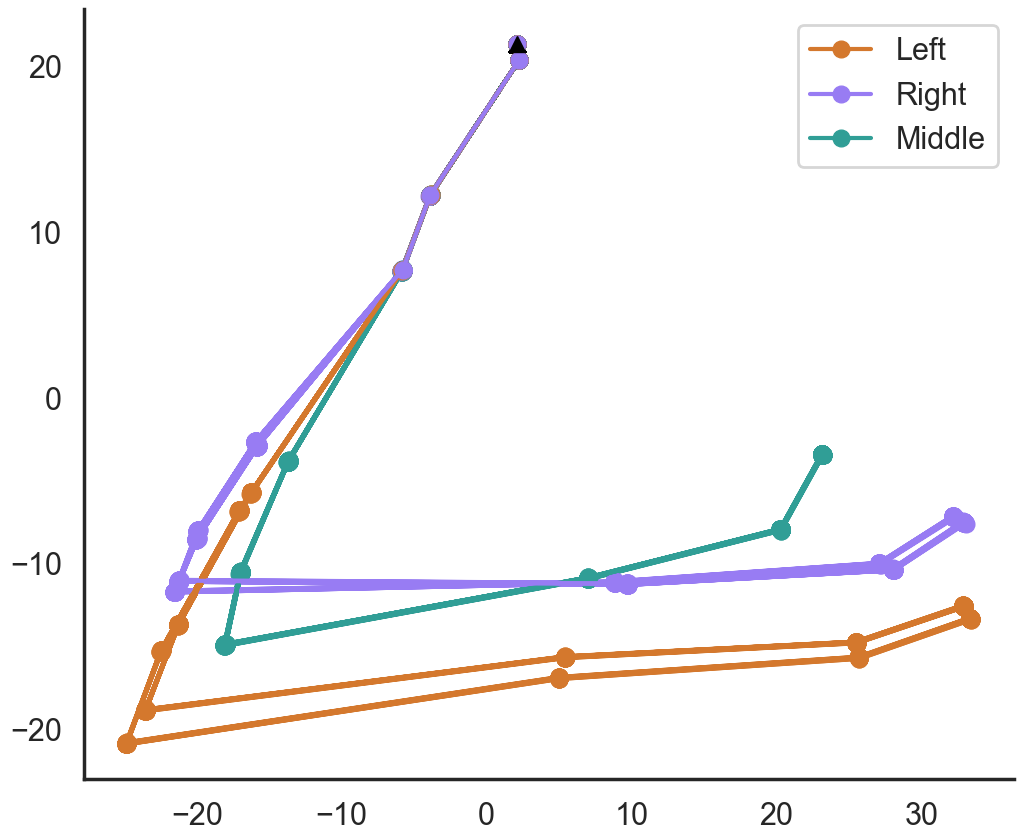

In [28]:
fig, ax = plt.subplots(figsize=(12, 10))
trial_infos = tam_infos["square-tam-horizontal"]

# Create empty lists to hold legend handles and labels
handles = []
labels = []
husl_palette = sns.husl_palette(12, s=0.9, l=0.6)

# Go through trials
for t in range(n_trials):

    # Transform each trial
    activity_pc = pca.transform(activity[t])  # (Time points, PCs)

    # Select this trial's ground truth
    trial = trial_infos[t]
    if trial['ground_truth'] == 1:
        motion = 'Left'
        color = husl_palette[1]
    elif trial['ground_truth'] == 2:
        motion = 'Middle'
        color = husl_palette[6]
    elif trial["ground_truth"] == 3:
        motion = 'Right'
        color=husl_palette[9]

    # Plot the PC activity
    p, = ax.plot(activity_pc[:, 0], activity_pc[:, 1], 'o-', color=color)

    # If this is the first time this type of motion is plotted, add it to the legend
    if motion not in labels:
        handles.append(p)
        labels.append(motion)

    # Plot the beginning of a trial with a special symbol
    _ = ax.plot(activity_pc[0, 0], activity_pc[0, 1], '^', color='black')

# Add a legend using the handles and labels lists
plt.legend(handles, labels)

# Change names
# ax.set_title(f'PCA')
# ax.set_xlabel('PC 1')
# ax.set_ylabel('PC 2')

plt.savefig(FIG_DIR / 'both_pca.png')

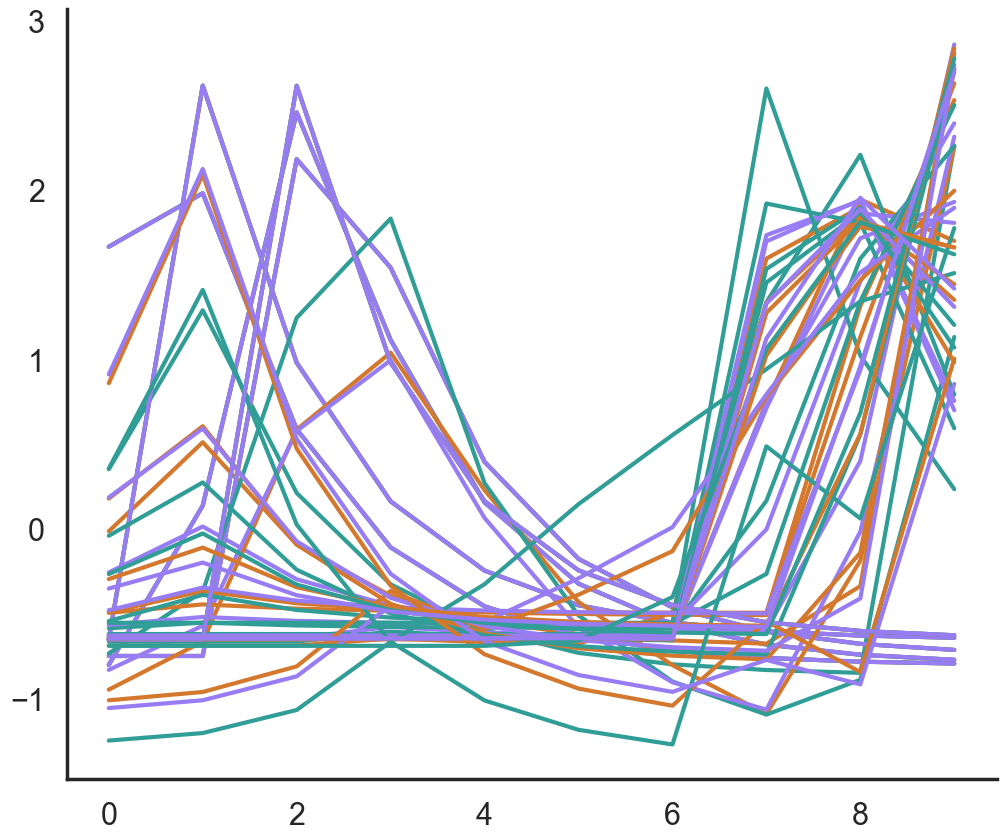

In [29]:
# Plot the top 10 neurons with the highest weights in the first PC
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
# fig.suptitle('Top 10 neurons with the highest weights in the first PC')
trial_infos = tam_infos["square-tam-horizontal"]

# Get the weights of the first PC
pc1_weights = pca.components_[0]  # (Neurons, )

# Get weights from the second PC
pc2_weights = pca.components_[1]  # (Neurons, )

# Get the indices of the top 10 neurons with the highest weights
top_neurons1 = np.argsort(pc1_weights)[-10:]
top_neurons2 = np.argsort(pc2_weights)[-10:]
top_neurons = np.unique(np.concatenate([top_neurons1, top_neurons2]))

data = np.stack(activity)
# Create empty lists to hold legend handles and labels
handles = []
labels = []

# Plot the activity of the top neurons
for n in top_neurons:

    # Find condition trials
    for condition in range(1, 4):
        trial_condition = [i for i, trial in enumerate(trial_infos) if trial['ground_truth'] == condition]

        # get neuron activity
        neuron_activity = data[trial_condition, :, n]  # (Trials, Time points)

        # Normalize
        normalized_data = np.apply_along_axis(zscore, 1, neuron_activity)

        # Average
        average_data = normalized_data.mean(axis=0)

        if condition == 1:
            motion = 'Left'
            color = husl_palette[1]
        elif condition == 2:
            motion = 'Middle'
            color = husl_palette[6]
        elif condition == 3:
            motion = 'Right'
            color = husl_palette[9]

        p, = ax.plot(average_data[:, ], color=color)

            # If this is the first time this type of motion is plotted, add it to the legend
        if motion not in labels:
            handles.append(p)
            labels.append(motion)

# Add a legend
# plt.legend()

# Change names
# ax.set_title(f'Top 10 neurons with the highest weights in the first PC')
# ax.set_xlabel('PC 1')
# ax.set_ylabel('PC 2')

plt.savefig(FIG_DIR / 'both_pca_neurons.png')

In [147]:
# Binning time points
n_bins = 3
bin_size = n_timepoints // n_bins
bins = np.histogram(np.arange(n_timepoints), n_bins)
bin_edges = np.floor(bins[1]).astype(int)

# Define PCA with 2 components
n_comps = 2
pca = PCA(n_components=n_comps)

# Initiate variables to keep track of top PCA neurons
n_top = 10  # number of top neurons with the highest weights in PCA
top_neurons = np.zeros((n_comps, n_top, n_bins))

# Loop through time bins
for i, tb in enumerate(bin_edges[:-1]):

    # Select activity across all trials and neurons for only this time bin
    bin_activity = np.concatenate([ac[tb: tb + bin_size] for ac in activity], axis=0)

    # Run PCA
    pca.fit(bin_activity)

    # Extract loadings
    loadings = pca.components_

    # Get index of top k neurons
    for pc in range(n_comps):
        neurons = np.argpartition(loadings[pc], -n_top)[-n_top:]
        top_neurons[pc, :, i] = neurons

In [148]:
# Gather the data from neurons of interest in a dataframe for easier plotting
data = {"NEURON":[], "TRIAL": [], "TIMEPOINT": [], "ACTIVITY": [], "TRIAL_TYPE": []}

# Find the highest activity neurons (without duplicates)
neurons = np.unique(top_neurons.flatten()).astype(int)

# Get the timeseries of activities
for n, neuron in enumerate(neurons):

    # Find the timeseries of activity of this neuron in all trials
    for trial in range(n_trials):
        for tp in range(n_timepoints):

            ac = activity[trial][tp, neuron]

            # Save to data
            data["NEURON"].append(neuron)
            data["TRIAL"].append(trial + 1)
            data["TIMEPOINT"].append(tp + 1)
            data["ACTIVITY"].append(ac)

            if trial_infos[trial]["ground_truth"] == 1:
                tt = "Right"
            elif trial_infos[trial]["ground_truth"] == 2:
                tt = "Mid"
            else:
                tt = "Left"
            data["TRIAL_TYPE"].append(tt)

# Turn into dataframe
df = pd.DataFrame(data)
df.head()

,NEURON,TRIAL,TIMEPOINT,ACTIVITY,TRIAL_TYPE
0,0,1,1,0.000000,Right
1,0,1,2,0.266061,Right
2,0,1,3,0.133030,Right
3,0,1,4,0.336075,Right
4,0,1,5,0.168037,Right


C:\Users\shari\AppData\Local\Temp\ipykernel_42428\45933666.py:34: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes.set_xticklabels(x_ticks)


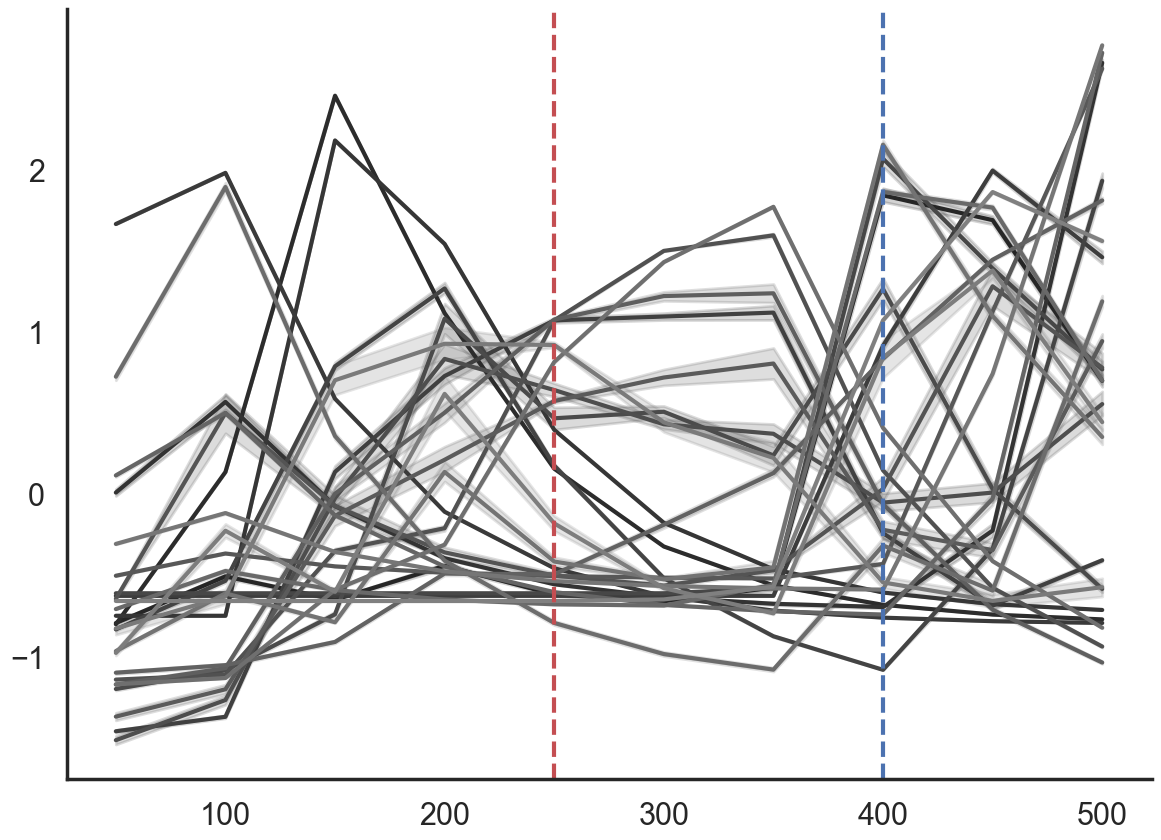

In [149]:
# Visualizing the activity of highest-loading neurons
fig, axes = plt.subplots(1, 1, figsize=(14, 10))
custom_pal = sns.color_palette("Paired", len(df.NEURON.unique()))
# fig.suptitle("Timeseries of 52 top PC Neurons")

# Normalize activity
plt_df = df.copy()
for neuron in neurons:
    for trial in plt_df.loc[df.NEURON == neuron, "TRIAL"].unique():
        plt_df.loc[(df.NEURON == neuron) & (df.TRIAL == trial), "NORM_ACTIVITY"] = zscore(
            plt_df.loc[(df.NEURON == neuron) & (df.TRIAL == trial), "ACTIVITY"]
        )

# Palette
custom_pal = sns.dark_palette("gray", n_colors=len(neurons))

# Plot the normalized activity
_plot = sns.lineplot(
    data=plt_df,
    x="TIMEPOINT",
    y="NORM_ACTIVITY",
    hue="NEURON",
    palette=custom_pal,
    ax=axes
)
# axes.set_ylabel("Normalized Activity")
_plot.legend_.remove()

# Change properties
# for i in range(2):
axes.set_xlabel("")
axes.set_ylabel("")
x_ticks = np.arange(0, 550, 100)
axes.set_xticklabels(x_ticks)
axes.axvline(x=5, color='r', ls='--')
axes.axvline(x=8, color='b', ls='--')

plt.savefig(FIG_DIR / 'both_pca_time.png')

In [33]:
def reshape_activity_for_rsa(activity, condition):
    # Select activity for this condition
    cond_activity = activity[condition]

    # Average across trials
    cond_activity = np.mean(cond_activity, axis=0)

    # Stack across timepoints
    cond_activity = cond_activity.reshape(-1)

    return cond_activity

In [40]:
# Construct a time point by neuron matrix (T, N) but only for times after 300ms (6th time point)
conditions = df.TRIAL_TYPE.unique()
n_conditions = len(conditions)
n_neurons = len(neurons)
n_trials = 100
cutoff = 5
slc_activity = np.zeros((n_conditions, n_trials, (n_timepoints - cutoff), n_neurons))

for trial in range(n_trials):
    for n, neuron in enumerate(neurons):
        ac = activity[trial][cutoff:, neuron]
        # ac = zscore(ac, axis=0, ddof=1)
        slc_activity[int(trial_infos[trial]["ground_truth"]) - 1, trial, :, n] = ac

# Compute correlation vectors to get (N, N) matrices for each condition
rdm = np.zeros((n_conditions, n_conditions))

for cond_one in range(n_conditions):

        # Select activity for this condition
        cond_one_activity = reshape_activity_for_rsa(slc_activity, cond_one)

        # second conditino
        for cond_two in range(n_conditions):

            # Select activity for this condition
            cond_two_activity = reshape_activity_for_rsa(slc_activity, cond_two)

            # Compute correlation matrix
            rdm[cond_one, cond_two] = 1 - np.corrcoef(cond_one_activity, cond_two_activity)[0, 1]

In [41]:
rdm

array([[2.22044605e-16, 1.51428777e-01, 2.51759821e-01],
       [1.51428777e-01, 0.00000000e+00, 3.22093447e-01],
       [2.51759821e-01, 3.22093447e-01, 0.00000000e+00]])

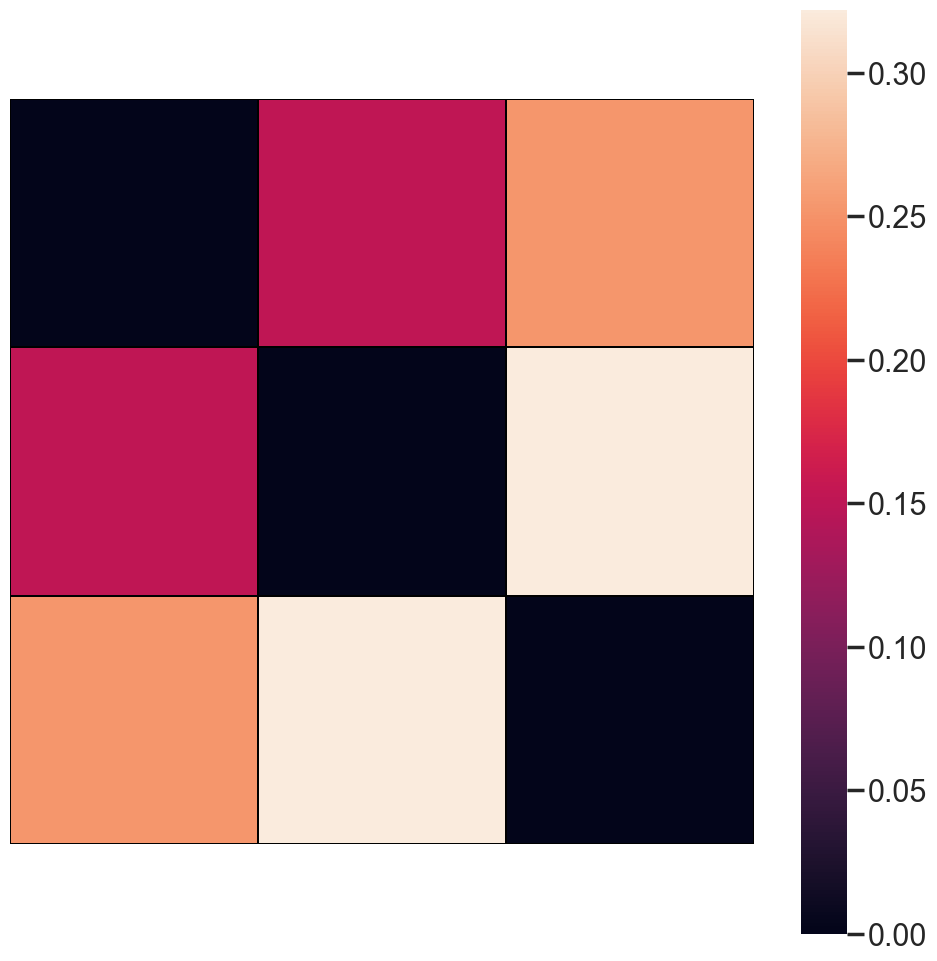

In [42]:
# Plot the neural RDMS
fig, ax = plt.subplots(figsize=(12, 12))
# condition_names = ["Right", "Mid", "Left"]

# plot
_plot = sns.heatmap(
    data=rdm,
    linewidths=.1,
    linecolor='black',
    square=True,
    # cmap="YlGnBu",
    ax=ax,
    # xticklabels=condition_names,
    xticklabels=[],
    # yticklabels=condition_names,
    yticklabels=[]
)
#
# ax.set_title("Motion RDM of highest activity neurons")
# ax.set_xlabel("Motion direction")
# ax.set_ylabel("Motion direction")
plt.savefig(FIG_DIR / 'both_rdm.png')

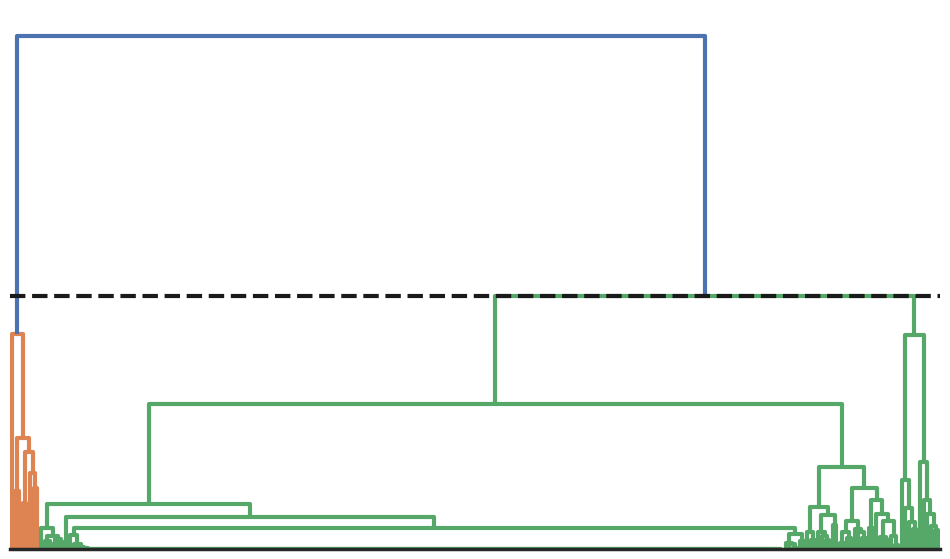

In [43]:
# Assuming your data is in an array called "data"
data = np.stack(activity)
n_clusters = 3

# # Reshape your data such that each neuron's activity is a single vector
X = data.reshape(-1, data.shape[-1])
# Initialize a StandardScaler
scaler = StandardScaler()

# Scale the data
data_scaled = scaler.fit_transform(X.T)

# Perform Agglomerative Clustering
clustering = AgglomerativeClustering(distance_threshold=0, n_clusters=None).fit(data_scaled)

# Create linkage matrix for dendrogram
counts = np.zeros(clustering.children_.shape[0])
n_samples = len(clustering.labels_)
for i, merge in enumerate(clustering.children_):
    current_count = 0
    for child_idx in merge:
        if child_idx < n_samples:
            current_count += 1  # leaf node
        else:
            current_count += counts[child_idx - n_samples]
    counts[i] = current_count

linkage_matrix = np.column_stack([clustering.children_, clustering.distances_, counts]).astype(float)

# Plot the dendrogram
fig, ax = plt.subplots(figsize=(12, 7))
# fig.suptitle('Clusters of units based on activity')

# Create a dendrogram using the linkage matrix
dendrogram = hierarchy.dendrogram(linkage_matrix, ax=ax, p=n_clusters)

# Determine the cut-off distance that will result in a specific number of clusters
num_clusters = 3  # the number of clusters you want
cut_off_distance = clustering.distances_[-(num_clusters-1)]

# Draw a horizontal line to cut dendrogram
ax.axhline(y=cut_off_distance, color='k', linestyle='--')
# Remove x ticks
ax.set_xticks([])
# ax.set_xlabel('Units')
# ax.set_ylabel('Distance')

# Remove spines
# for spine in ax.spines.values():
#     spine.set_visible(False)
# remove y spine
ax.spines["left"].set_visible(False)

# Remove y axis
ax.yaxis.set_visible(False)
plt.show()

fig.savefig(FIG_DIR / 'both_clusters-3.png')

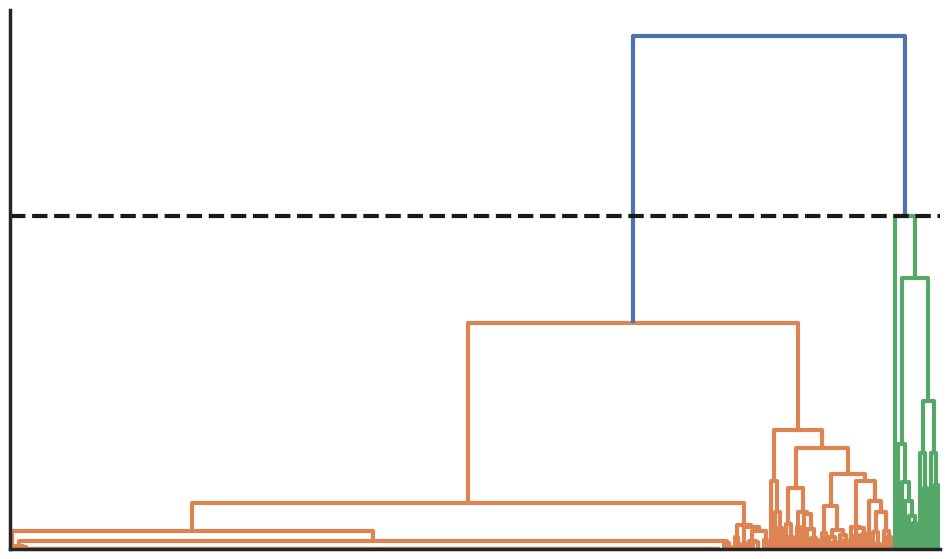

In [44]:
# Assuming your data is in an array called "data"
data = np.stack(activity)
n_clusters = 3

# # Reshape your data such that each neuron's activity is a single vector
X = data.reshape(-1, data.shape[-1])

# Perform Agglomerative Clustering
clustering = AgglomerativeClustering(distance_threshold=0, n_clusters=None).fit(X.T)

# Create linkage matrix for dendrogram
counts = np.zeros(clustering.children_.shape[0])
n_samples = len(clustering.labels_)
for i, merge in enumerate(clustering.children_):
    current_count = 0
    for child_idx in merge:
        if child_idx < n_samples:
            current_count += 1  # leaf node
        else:
            current_count += counts[child_idx - n_samples]
    counts[i] = current_count

linkage_matrix = np.column_stack([clustering.children_, clustering.distances_, counts]).astype(float)

# Plot the dendrogram
fig, ax = plt.subplots(figsize=(12, 7))
# fig.suptitle('Clusters of units based on activity')

# Create a dendrogram using the linkage matrix
dendrogram = hierarchy.dendrogram(linkage_matrix, ax=ax, p=n_clusters)

# Determine the cut-off distance that will result in a specific number of clusters
# num_clusters = 4  # the number of clusters you want
cut_off_distance = clustering.distances_[-(n_clusters-1)]

# Draw a horizontal line to cut dendrogram
ax.axhline(y=cut_off_distance, color='k', linestyle='--')
# Remove x ticks
ax.set_xticks([])
# ax.set_xlabel('Units')
# ax.set_ylabel('Distance')

# Remove spines
# for spine in ax.spines.values():
#     spine.set_visible(False)
# remove y spine
# ax.spines["left"].set_visible(False)

# Remove y axis
# ax.yaxis.set_visible(False)
ax.set_yticklabels([])
plt.show()

fig.savefig(FIG_DIR / 'both_clusters-3.png')

C:\Users\shari\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_agglomerative.py:983: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(


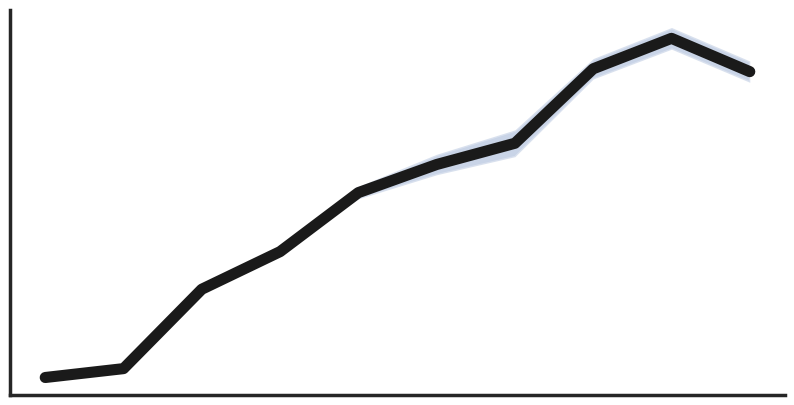

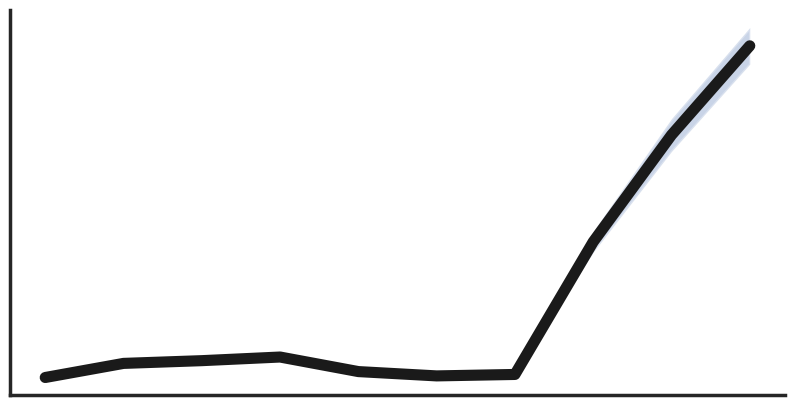

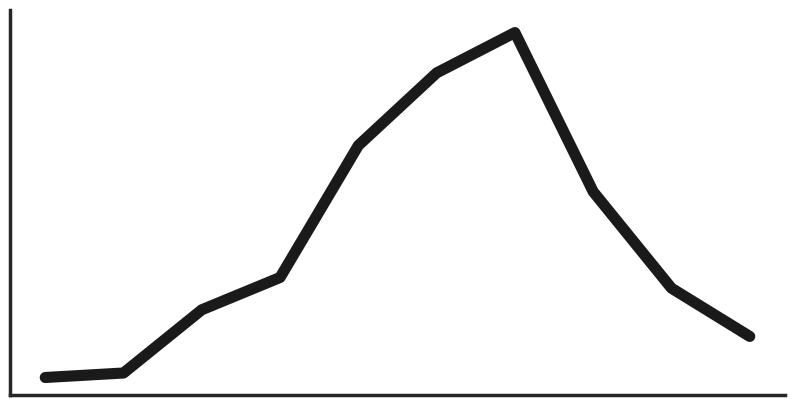

In [45]:
# Initialize a StandardScaler
X = data.reshape(-1, data.shape[-1])
n_clusters = 3
# Perform Agglomerative Clustering
cluster = AgglomerativeClustering(n_clusters=n_clusters, affinity='euclidean', linkage='ward')
cluster.fit_predict(X.T)

# Get the unique labels (clusters)
unique_labels = np.unique(cluster.labels_)

# Create a dictionary to store the neuron indices for each cluster
cluster_dict = {}

# Iterate over unique labels
for label in unique_labels:
    # Get the indices of neurons belonging to this cluster
    neuron_indices = np.where(cluster.labels_ == label)[0]
    # Store the indices in the dictionary
    cluster_dict[label] = neuron_indices

# Initialize a figure with multiple subplots

# Iterate over the clusters
for idx, (cluster, neuron_indices) in enumerate(cluster_dict.items()):
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))

    # Get the corresponding data for the neurons in this cluster
    cluster_data = data[:, :, neuron_indices]

    # Compute the average timecourse
    avg_timecourse = cluster_data.mean(axis=0).mean(axis=1)

    # Compute the standard error of the mean across trials
    sem_timecourse = cluster_data.std(axis=0).mean(axis=1) / np.sqrt(n_trials)

    # Plot the average timecourse on its own subplot
    ax.plot(avg_timecourse, color="k", linewidth=8)

    # Plot the error bands
    ax.fill_between(range(n_timepoints), avg_timecourse - sem_timecourse, avg_timecourse + sem_timecourse, alpha=0.3)

    # ax.set_title(f"Cluster {cluster + 1}")

    # Add explicit xticklabels from 0 to 500 ms
    # ax.set_xticklabels(np.arange(0, 501, 100))

    # Add xlabel
    ax.set_xlabel('')
    ax.set_xticklabels([])

    # Add ylabel
    ax.set_ylabel('')
    ax.set_yticklabels([])

    # Add line at 300ms
    # ax.axvline(x=4, color='r', linestyle='--')

    # Show the plot
    # plt.tight_layout()
    # plt.show()

    # save
    fig.savefig(str(FIG_DIR / f'both_cluster{idx+1}_256_clusters-3.png'))




C:\Users\shari\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_agglomerative.py:983: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(


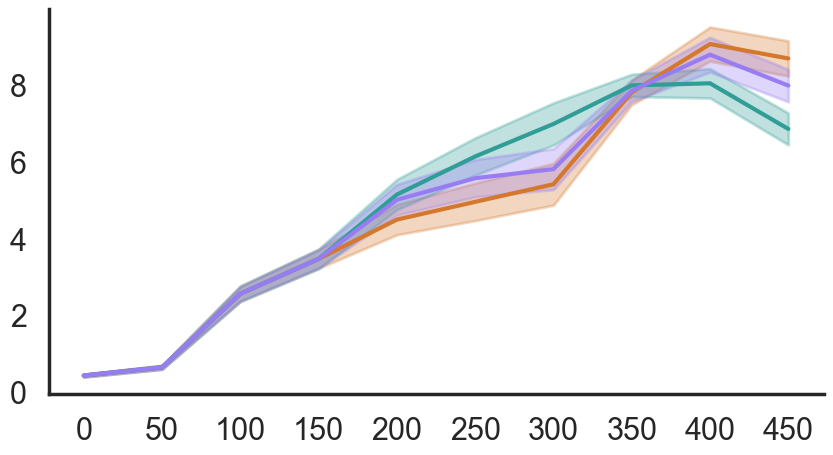

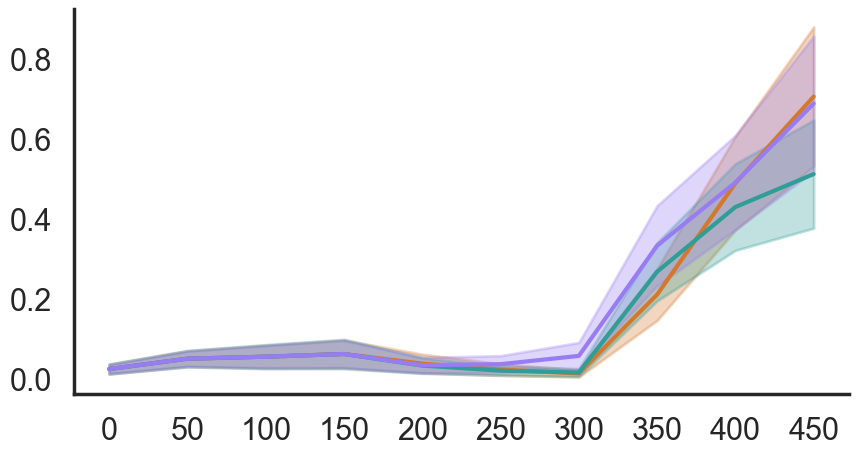

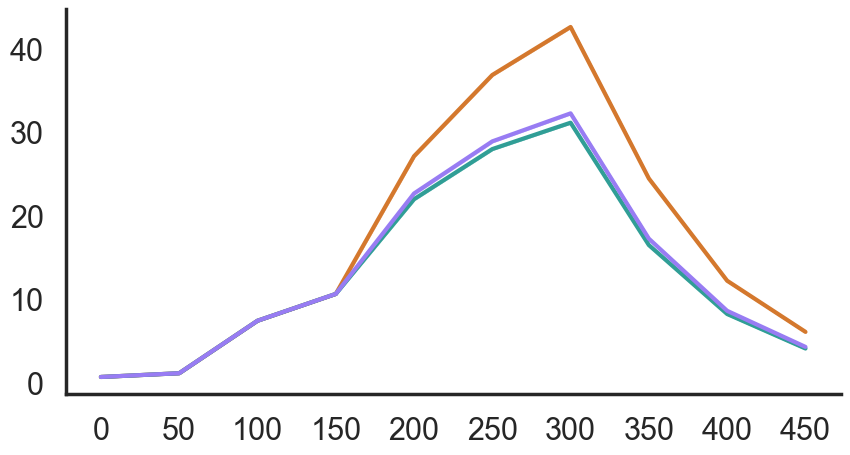

In [150]:
# Initialize a StandardScaler
data = np.stack(activity)
X = data.reshape(-1, data.shape[-1])
n_clusters = 3
trial_infos = tam_infos["square-tam-horizontal"]


# Define your trial conditions and corresponding colors
trial_conditions = [1, 2, 3]
# colors = ['red', 'green', 'blue']
husl_palette = sns.husl_palette(12, s=0.9, l=0.6)
colors = [husl_palette[1], husl_palette[6], husl_palette[9]]
color_map = dict(zip(trial_conditions, colors))

# Perform Agglomerative Clustering
cluster = AgglomerativeClustering(n_clusters=n_clusters, affinity='euclidean', linkage='ward')
cluster.fit_predict(X.T)

# Get the unique labels (clusters)
unique_labels = np.unique(cluster.labels_)

# Create a dictionary to store the neuron indices for each cluster
cluster_dict = {}

# Iterate over unique labels
for label in unique_labels:
    # Get the indices of neurons belonging to this cluster
    neuron_indices = np.where(cluster.labels_ == label)[0]
    # Store the indices in the dictionary
    cluster_dict[label] = neuron_indices

# Initialize a figure with multiple subplots
# fig, axs = plt.subplots(len(unique_labels), 1, figsize=(10, len(unique_labels)*5))

# Iterate over the clusters
for idx, (cluster, neuron_indices) in enumerate(cluster_dict.items()):
    fig, axs = plt.subplots(1, 1, figsize=(10, 5))
    # Get the corresponding data for the neurons in this cluster
    cluster_data = data[:, :, neuron_indices]

    # Compute the average timecourse for each condition
    for condition in trial_conditions:
        # Get the indices of trials for this condition
        condition_indices = [i for i, trial_info in enumerate(trial_infos) if trial_info["ground_truth"] == condition]

        # Get the corresponding data for these trials
        condition_data = cluster_data[condition_indices, :, :]

        # Normalize
        normalized_data = np.apply_along_axis(zscore, 1, condition_data)

        # Compute the average timecourse and the standard error of the mean
        avg_timecourse = condition_data.mean(axis=0)
        sem_timecourse = avg_timecourse.std(axis=1) / np.sqrt(len(condition_indices))
        avg_all = avg_timecourse.mean(axis=1)

        # Plot the average timecourse and error bands with the corresponding color
        axs.plot(avg_all, color=color_map[condition])
        axs.fill_between(range(n_timepoints), avg_all - sem_timecourse, avg_all + sem_timecourse, color=color_map[condition], alpha=0.3)

        # axs.set_title(f"Cluster {cluster + 1}")

        # Add explicit xticklabels from 0 to 500 ms
        # print(axs.get_xticks())
        plt.xticks()

        axs.set_xticks(np.arange(0, 10))
        axs.set_xticklabels(np.arange(0, 500, 50))
    # Add xlabel
    # axs.set_xlabel('Time (ms)')

    # Add ylabel
    # axs.set_ylabel('Average activity (a.u.)')

    # Add line at 300ms
    # axs.axvline(x=4, color='k', linestyle='--')


    # Show the plot
    # plt.tight_layout()
    plt.show()

    # save
    fig.savefig(str(FIG_DIR / f'both_cluster-{cluster + 1}_profile_256_clusters-3.png'))

In [70]:
df = pd.DataFrame(columns=["Cluster", "Dataset", "Accuracy"])
cluster_data = []
dataset_data = []
acc_data = []

for cluster in range(4):

    for i in range(100):
        net = TAMNet(
            dataset=tam_test_datasets["square-tam-horizontal"],
            hidden_size=256,
            output_size=tam_test_datasets["square-tam-horizontal"].env.action_space.n,
            learning_rate=0.000001,
            device=device
        )
        # Load the trained weights
        net.RNN.load_state_dict(torch.load(MODEL_DIR / 'learned_horiz_both.pt'))
        net.RNN.rnn.eval()
        net.RNN.eval()

        if cluster == 3:
            neurons = np.arange(0, 256)
        else:
            neurons = cluster_dict[cluster]
        if cluster == 3:
            random_neurons = np.random.choice(neurons, neurons.shape[0] // 6, replace=False)
        else:
            random_neurons = np.random.choice(neurons, neurons.shape[0] // 2 , replace=False)
        # random_neurons = np.random.choice(neurons, neurons.shape[0] // 4, replace=False)
        net.RNN.rnn.h2h.weight.data[:, random_neurons] = 0
        net.RNN.fc.weight.data[:, random_neurons] = 0

        # Test on datasets
        for et, dataset in tam_test_datasets.items():
            _, _, test_acc = net.test_rnn(100, dataset)

            cluster_data.append(cluster + 1)
            dataset_data.append(et)
            acc_data.append(test_acc)

        for et, dataset in motion_test_datasets.items():
            _, _, test_acc = net.test_rnn(100, dataset)

            cluster_data.append(cluster + 1)
            dataset_data.append(et)
            acc_data.append(test_acc)

df["Cluster"] = cluster_data
df["Dataset"] = dataset_data
df["Accuracy"] = acc_data

In [52]:
ns = []
for cluster in range(3):
    neurons = cluster_dict[cluster]
    ns.append(neurons.shape[0])

avg = np.mean(ns, axis=0)
avg

85.33333333333333

In [53]:
ns

[12, 243, 1]

In [54]:
85 / 256

0.33203125

In [96]:
list(tam_test_datasets.keys()) + list(motion_test_datasets.keys())

['square-tam-horizontal',
 'square-outline-horizontal',
 'circle-tam-horizontal',
 'circle-outline-horizontal',
 'triangle-tam-horizontal',
 'triangle-outline-horizontal',
 'square-cnt-horizontal',
 'circle-cnt-horizontal',
 'triangle-cnt-horizontal']

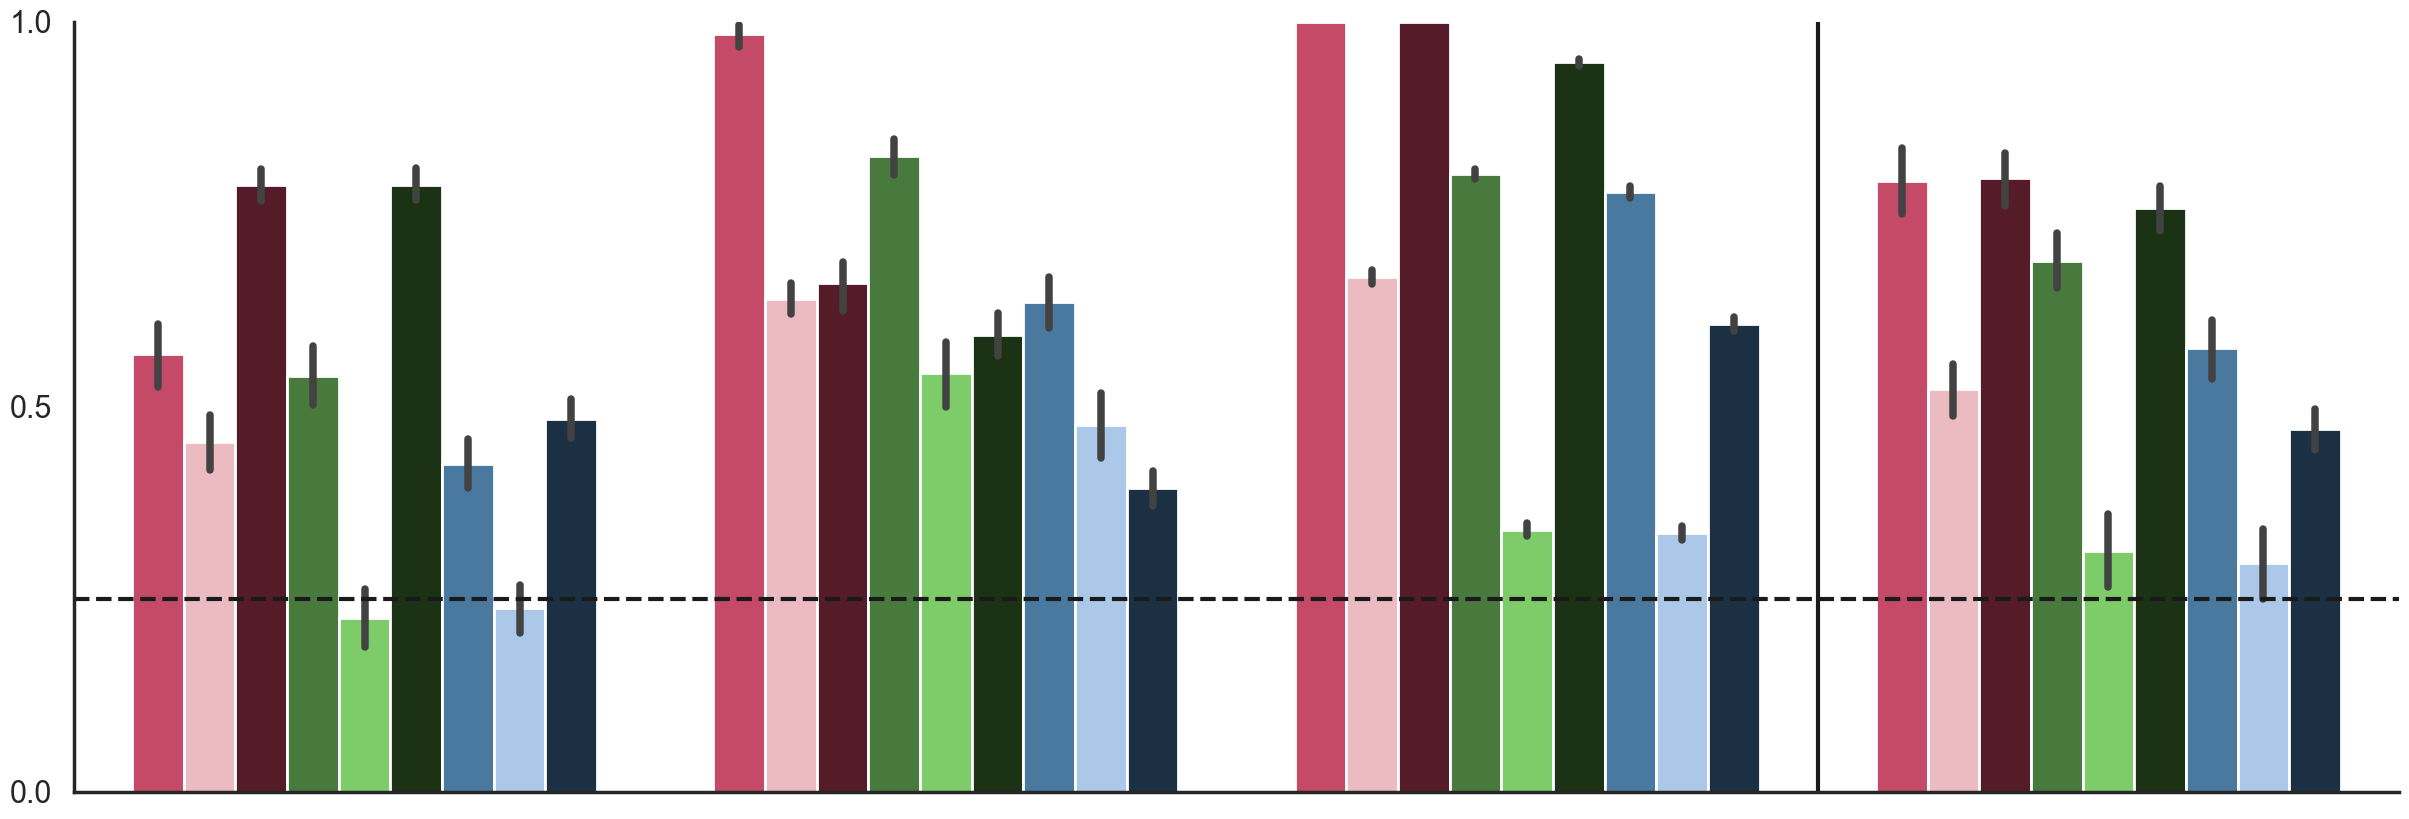

In [100]:
# plot the accuracy
fig, ax = plt.subplots(figsize=(30, 10))
# Define colors
colors_high_sat = sns.husl_palette(3, s=0.8, l=0.5)  # 3 colors with high saturation
colors_low_sat = sns.husl_palette(3, s=0.8, l=0.8)  # 3 colors with low saturation

# Create a new list by interweaving the two color lists
colormap = [val for pair in zip(colors_high_sat, colors_low_sat, colors_super_sat) for val in pair]

p = sns.barplot(
    data=df,
    x="Cluster",
    y="Accuracy",
    hue="Dataset",
    hue_order=['square-tam-horizontal',
 'square-outline-horizontal', 'square-cnt-horizontal', 'circle-tam-horizontal',
 'circle-outline-horizontal', 'circle-cnt-horizontal', 'triangle-tam-horizontal',
 'triangle-outline-horizontal', 'triangle-cnt-horizontal'],
    ax=ax,
    palette=colormap
)
ax.legend_.remove()
ax.set_ylim(0, 1)
ax.set_ylabel("")
ax.set_xlabel("")
ax.set_xticklabels([])
# ax.set_title("Accuracy of Lesioned Networks")
ax.axhline(y=0.25, color='k', ls='--')
# vertical line after first four bars
ax.axvline(x=2.5, color='k', ls='-')
# rotate xticks
# Change legend labels to be more descriptive
# handles, labels = ax.get_legend_handles_labels()
# ax.legend(handles=handles, labels=[label[:-11] for label in labels])

# plt.setp(ax.get_xticklabels(), rotation=45, horizontalalignment='right')
# plt.ylim(0, 1.5)
plt.yticks(np.arange(0, 1.5, 0.5))
# plt.tight_layout()
plt.show()
# Save
fig.savefig(str(FIG_DIR / "both_lesion_analysis.png"))

In [91]:
# Load the trained weights
net = TAMNet(
    dataset=tam_test_datasets["square-tam-horizontal"],
    hidden_size=256,
    output_size=tam_test_datasets["square-tam-horizontal"].env.action_space.n,
    learning_rate=0.001,
    device=device
)
net.RNN.load_state_dict(torch.load(MODEL_DIR / 'learned_horiz_both.pt'))
net.RNN.eval()
net.RNN.rnn.eval()


CTRNN(
  (input2h): Linear(in_features=1024, out_features=256, bias=True)
  (h2h): Linear(in_features=256, out_features=256, bias=True)
)

In [107]:
orig_tam_acc.mean(axis=1)

array([1.    , 0.6714, 0.8172, 0.3276, 0.772 , 0.3346])

In [108]:
orig_motion_acc.mean(axis=1)

array([1.    , 0.9428, 0.613 ])

In [117]:
import numpy as np
from scipy import stats

# Assume `acc` is your accuracy list/array
# Here, 0.25 is the chance level
for i, (et, dataset) in enumerate(tam_test_datasets.items()):
    accuracies = orig_tam_acc[i, :]
    w_stat, p_value = stats.wilcoxon(accuracies - 0.25)
    print(f"Dataset {et}, W-statistic: {w_stat}, mean: {accuracies.mean()} P-value: {np.round(p_value, 8)}")

Dataset square-tam-horizontal, W-statistic: 0.0, mean: 1.0 P-value: 0.0
Dataset square-outline-horizontal, W-statistic: 0.0, mean: 0.6714000000000001 P-value: 0.0
Dataset circle-tam-horizontal, W-statistic: 0.0, mean: 0.8172 P-value: 0.0
Dataset circle-outline-horizontal, W-statistic: 19.0, mean: 0.3276 P-value: 1e-08
Dataset triangle-tam-horizontal, W-statistic: 0.0, mean: 0.7719999999999999 P-value: 0.0
Dataset triangle-outline-horizontal, W-statistic: 6.0, mean: 0.33460000000000006 P-value: 0.0


C:\Users\shari\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "


In [105]:
import numpy as np
from scipy import stats

# Assume `acc` is your accuracy list/array
# Here, 0.25 is the chance level
for i, (et, dataset) in enumerate(motion_test_datasets.items()):
    accuracies = orig_motion_acc[i, :]
    w_stat, p_value = stats.wilcoxon(accuracies - 0.25)
    print(f"Dataset {et}, W-statistic: {w_stat}, P-value: {np.round(p_value, 8)}")

Dataset square-cnt-horizontal, W-statistic: 0.0, P-value: 0.0
Dataset circle-cnt-horizontal, W-statistic: 0.0, P-value: 0.0
Dataset triangle-cnt-horizontal, W-statistic: 0.0, P-value: 0.0


In [118]:

observed_diffs = []
p_values = np.zeros((len(tam_test_datasets), 4))
# Assume `acc1` and `acc2` are your accuracy lists/arrays
for cluster in range(4):
    for i, (et, dataset) in enumerate(tam_test_datasets.items()):

        # acc1 = df.loc[(df.Dataset == et) & (df.Cluster == 4), "Accuracy"]
        acc1 = orig_tam_acc[i, :]
        acc2 = df.loc[(df.Dataset == et) & (df.Cluster == cluster + 1), "Accuracy"]
        t, p = stats.ttest_ind(acc1, acc2)
        # print(f"Dataset: {et}, Cluster: {cluster}, t: {t}, p: {p}")

        observed_diff = np.mean(acc1) - np.mean(acc2)
        observed_diffs.append(observed_diff)

        combined = np.concatenate((acc1, acc2))

        n_permutations = 10000
        count = 0
        for _ in range(n_permutations):
            permuted = np.random.permutation(combined)
            perm_acc1 = permuted[:len(acc1)]
            perm_acc2 = permuted[len(acc1):]
            perm_diff = np.mean(perm_acc1) - np.mean(perm_acc2)
            if abs(perm_diff) >= abs(observed_diff):
                count += 1

        p_value = count / n_permutations
        p_values[i, cluster] = p_value
        # print(f"P-value: {p_value}")

C:\Users\shari\AppData\Local\Temp\ipykernel_42428\2859919281.py:10: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  t, p = stats.ttest_ind(acc1, acc2)


In [119]:
p_values

array([[0.000e+00, 1.955e-01, 1.000e+00, 0.000e+00],
       [0.000e+00, 3.140e-02, 7.048e-01, 0.000e+00],
       [0.000e+00, 6.573e-01, 1.530e-02, 0.000e+00],
       [2.000e-04, 0.000e+00, 1.362e-01, 6.784e-01],
       [0.000e+00, 0.000e+00, 3.398e-01, 0.000e+00],
       [0.000e+00, 0.000e+00, 9.584e-01, 2.495e-01]])

In [120]:
observed_diffs = []
p_values = np.zeros((len(motion_test_datasets), 4))
# Assume `acc1` and `acc2` are your accuracy lists/arrays
for cluster in range(4):
    for i, (et, dataset) in enumerate(motion_test_datasets.items()):

        # acc1 = df.loc[(df.Dataset == et) & (df.Cluster == 4), "Accuracy"]
        acc1 = orig_motion_acc[i, :]
        acc2 = df.loc[(df.Dataset == et) & (df.Cluster == cluster + 1), "Accuracy"]
        t, p = stats.ttest_ind(acc1, acc2)
        # print(f"Dataset: {et}, Cluster: {cluster}, t: {t}, p: {p}")

        observed_diff = np.mean(acc1) - np.mean(acc2)
        observed_diffs.append(observed_diff)

        combined = np.concatenate((acc1, acc2))

        n_permutations = 10000
        count = 0
        for _ in range(n_permutations):
            permuted = np.random.permutation(combined)
            perm_acc1 = permuted[:len(acc1)]
            perm_acc2 = permuted[len(acc1):]
            perm_diff = np.mean(perm_acc1) - np.mean(perm_acc2)
            if abs(perm_diff) >= abs(observed_diff):
                count += 1

        p_value = count / n_permutations
        p_values[i, cluster] = p_value
        # print(f"P-value: {p_value}")

C:\Users\shari\AppData\Local\Temp\ipykernel_42428\1569391610.py:10: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  t, p = stats.ttest_ind(acc1, acc2)


In [121]:
p_values

array([[0.    , 0.    , 1.    , 0.    ],
       [0.    , 0.    , 0.2976, 0.    ],
       [0.    , 0.    , 0.4891, 0.    ]])

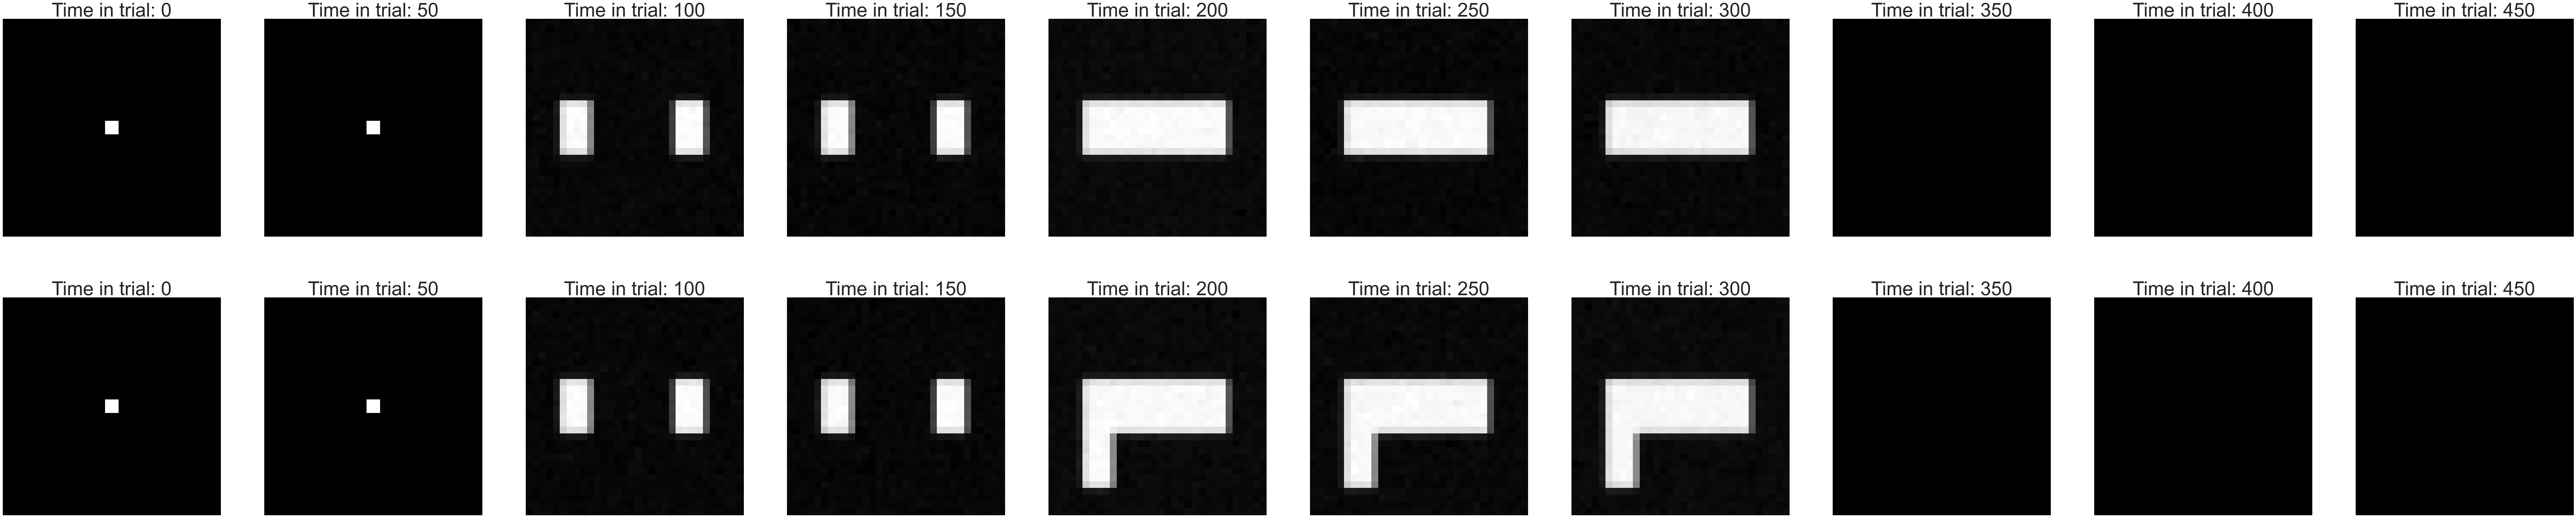

In [137]:
from src.train_test_utils import plot_dataset
plot_dataset(2, tam_test_datasets["square-tam-horizontal"], FIG_DIR)

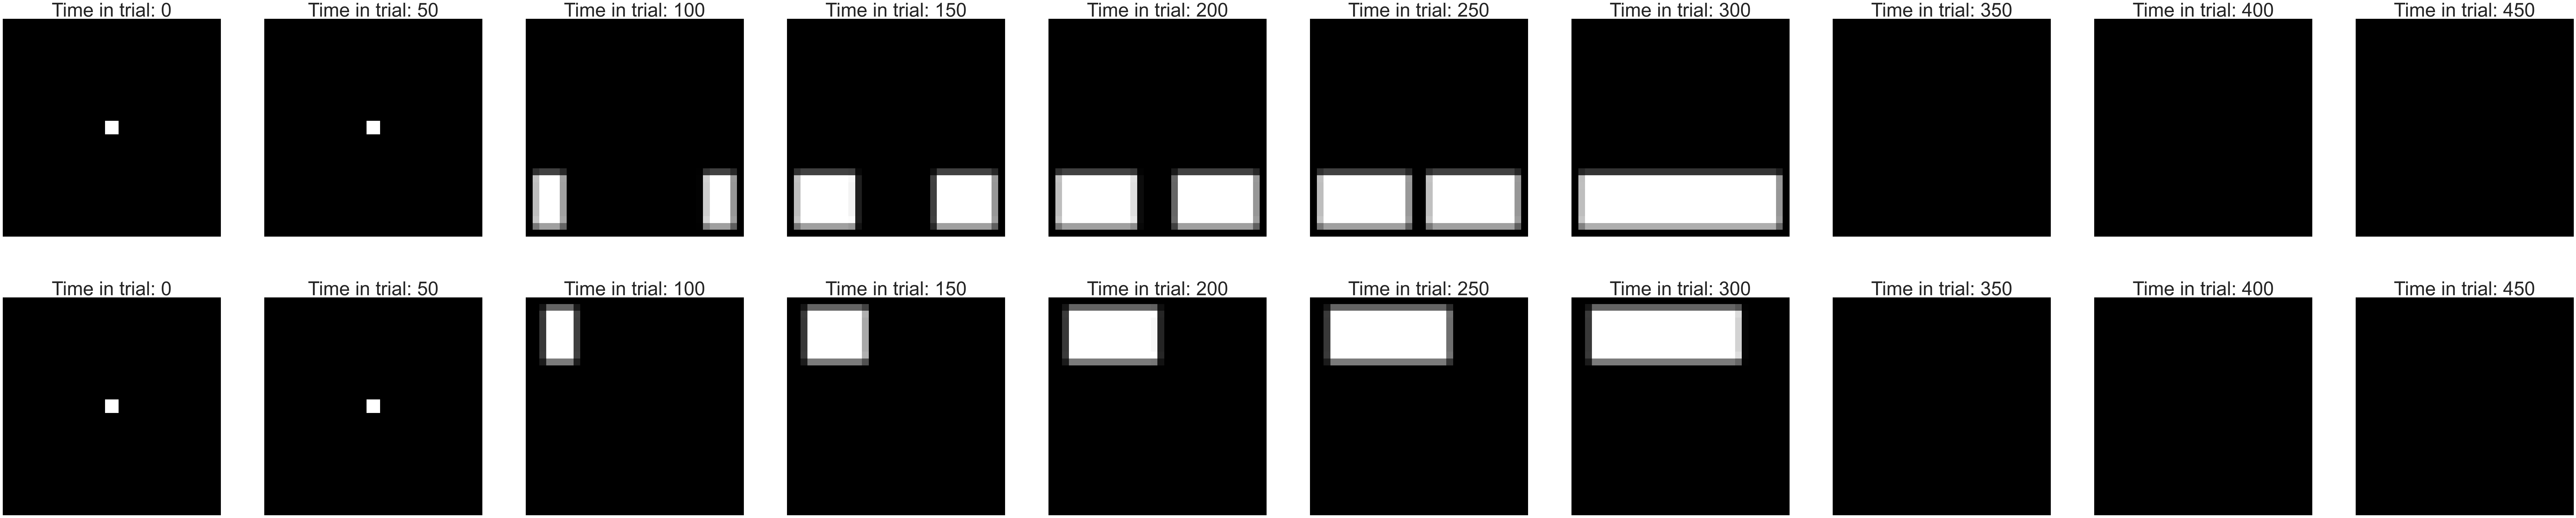

In [141]:
plot_dataset(2, motion_test_datasets["square-cnt-horizontal"], FIG_DIR)